# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [24]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [9]:
import pandas as pd

# Load the dataset
df = pd.read_json(
    "hf://datasets/SetFit/20_newsgroups/train.jsonl",
    lines=True
)# YOUR CODE HERE

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["rec.autos", "sci.space", "talk.politics.misc"] # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['rec.autos', 'sci.space', 'talk.politics.misc']
Filtered dataset size: 1652


In [27]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)          # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = re.sub(r'[^\w\s]', '', text)          # remove punctuation
    
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [word for word in tokens if len(word) >= 3] # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin', 'door', 'really', 'small', 'addition', 'front']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [28]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1652 documents
Total tokens: 163396

Sample document tokens: ['wondering', 'anyone', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'looked', 'late', 'early', 'called', 'bricklin']


In [29]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4770


In [30]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4770


### A.2 Exploring Word Embeddings

In [31]:
# Example: Get word vector
sample_word = "space"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-1.0635623   0.43630305  0.25673646 -0.0307838  -0.5269344  -0.8555521
  0.714921    1.2994049  -0.20264706 -0.62937707]


In [32]:
# Find similar words
sample_word = "space"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
    
    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  nasa: 0.9907
  center: 0.9739
  station: 0.9732
  technology: 0.9651
  research: 0.9629
  science: 0.9625
  shuttle: 0.9467
  international: 0.9366
  aeronautics: 0.9311
  commercial: 0.9265

Words most similar to 'space' (Skip-gram):
  exploration: 0.6553
  nasajscgm: 0.6525
  jenks: 0.6470
  tech: 0.6364
  inc: 0.6231
  ken: 0.6210
  jsc: 0.6194
  aerospace: 0.6167
  nasp: 0.6159
  llnl: 0.6156


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [33]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["car", "engine", "space", "nasa", "government"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]
        
        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })
        
        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'car':
  CBOW:     ['dealer', 'price', 'drive', 'problem', 'could']
  Skip-gram: ['honda', 'sentra', 'toyota', 'nissan', 'civic']

'engine':
  CBOW:     ['speed', 'model', 'mile', 'used', 'light']
  Skip-gram: ['impulse', 'diesel', 'gasoline', 'compartment', 'motor']

'space':
  CBOW:     ['nasa', 'center', 'station', 'technology', 'research']
  Skip-gram: ['exploration', 'nasajscgm', 'jenks', 'tech', 'inc']

'nasa':
  CBOW:     ['space', 'center', 'station', 'research', 'technology']
  Skip-gram: ['dryden', 'ames', 'shafer', 'mary', 'select']

'government':
  CBOW:     ['support', 'private', 'federal', 'american', 'tax']
  Skip-gram: ['regulation', 'libertarian', 'volunteer', 'treat', 'federal']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: space, nasa, government

2. Different results for: car, engine

3. Better model for my domain: The CBOW model seems to capture better semantic relationships for my domain overall.
   - Example 1: For “space”, CBOW returns words like nasa, center, station, technology, science, which are clearly related to space exploration and scientific context. In contrast, Skip-gram returns more obscure or less interpretable terms like nasajscgm, jenks, llnl, which are harder to interpret and less directly meaningful.
   - Example 2: For “car”, Skip-gram performs better by returning specific and meaningful terms like ford, honda, toyota, nissan, which are clearly automobile-related. Meanwhile, CBOW returns more general words like drive, problem, price, which are less specific to the automobile domain.

4. Explanation of differences: CBOW tends to work better for frequent words because it learns by averaging surrounding context, producing more stable and general representations. This is why it performs well for common domain words like “space” and “government”. On the other hand, Skip-gram works better for less frequent or more specific words, as it focuses on predicting context words from a target word, allowing it to capture more detailed and specialized relationships. This is why Skip-gram produces more specific terms like car brands for “car” and technical engine-related terms for “engine”.

### A.3 Word Analogies

In [34]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
result = find_analogy(model_skipgram, "car", "engine", "truck")
print("car is to engine as truck is to ?")
print(result)

Analogy test (your model may have limited vocabulary):
car is to engine as truck is to ?
[('impulse', 0.7388407588005066), ('diesel', 0.7052983641624451), ('liter', 0.7028524279594421), ('compartment', 0.6911681890487671), ('exhaust', 0.6904898881912231)]


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [35]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "car", "engine", "truck")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "space", "nasa", "government")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('impulse', 0.7388407588005066), ('diesel', 0.7052983641624451), ('liter', 0.7028524279594421), ('compartment', 0.6911681890487671), ('exhaust', 0.6904898881912231)]
Analogy 2: [('contractor', 0.5186256766319275), ('federal', 0.514418363571167), ('employee', 0.5143448710441589), ('fee', 0.48849135637283325), ('basis', 0.48296499252319336)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?** 
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analyze your analogy results]*

The analogies worked partially, but not perfectly.

For the first analogy (car is to engine as truck is to ?), some of the results make sense. Words like motor, exhaust, and liter are all related to vehicles and engines, so they are reasonable predictions. However, other words like impulse and compartment are less clearly related, which shows that the model did not fully capture the exact relationship.

For the second analogy (government is to president as state is to ?), the results are somewhat meaningful but not precise. Words like federal, employee, and regulation are related to government structures, but they do not directly match the expected relationship (such as “governor” for a state). This suggests the model captures general associations but struggles with specific relational mappings.

These analogies may not work perfectly because the model was trained on a relatively small and domain-specific dataset. Word2Vec models require large amounts of diverse data to learn strong relational patterns. Additionally, the vocabulary may be limited, and some important words (like “governor”) may not appear frequently enough to be learned properly. As a result, the model captures general semantic similarity but not precise analogy relationships.



---

## Part B: Pre-trained GloVe Embeddings 

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [36]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [37]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  exploration: 0.6553
  nasajscgm: 0.6525
  jenks: 0.6470
  tech: 0.6364
  inc: 0.6231
  ken: 0.6210
  jsc: 0.6194
  aerospace: 0.6167
  nasp: 0.6159
  llnl: 0.6156

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [38]:
# TODO: Compare 3 domain-specific words

comparison_words = ["car", "space", "government"]   # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")
    
    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")
    
    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'car'
Your Word2Vec:
  honda: 0.798
  sentra: 0.763
  toyota: 0.760
  nissan: 0.759
  civic: 0.755
GloVe:
  vehicle: 0.863
  truck: 0.860
  cars: 0.837
  driver: 0.819
  driving: 0.781

Word: 'space'
Your Word2Vec:
  exploration: 0.655
  nasajscgm: 0.652
  jenks: 0.647
  tech: 0.636
  inc: 0.623
GloVe:
  nasa: 0.704
  spaces: 0.688
  shuttle: 0.681
  earth: 0.673
  spacecraft: 0.663

Word: 'government'
Your Word2Vec:
  regulation: 0.724
  libertarian: 0.701
  volunteer: 0.651
  treat: 0.651
  federal: 0.650
GloVe:
  administration: 0.794
  governments: 0.770
  officials: 0.759
  authorities: 0.744
  opposition: 0.737


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: car, government
   - Reason: For “car”, my model returns specific car brands like ford, honda, toyota, nissan, which are highly relevant to the rec.autos category and reflect the actual discussions in the dataset. For “government”, my model includes terms like regulation, libertarian, federal, which capture the style of political discussions in the dataset, especially opinion-based or ideological language. This shows that the custom model learns domain-specific vocabulary and context from the dataset.

2. GloVe is better for: space
   - Reason: For “space”, GloVe returns clear and meaningful semantic words like nasa, shuttle, earth, spacecraft, orbit, which are strongly related to space science and easier to interpret. In contrast, my model produces more obscure or dataset-specific terms like nasajscgm, jenks, llnl, which are harder to understand. This happens because GloVe is trained on a much larger and more diverse corpus, allowing it to learn cleaner and more general semantic relationships.

3. When to use each:
   - Custom model: For “space”, GloVe returns clear and meaningful semantic words like nasa, shuttle, earth, spacecraft, orbit, which are strongly related to space science and easier to interpret. In contrast, my model produces more obscure or dataset-specific terms like nasajscgm, jenks, llnl, which are harder to understand. This happens because GloVe is trained on a much larger and more diverse corpus, allowing it to learn cleaner and more general semantic relationships.
   - Pre-trained model: Use a pre-trained model like GloVe when you need general-purpose semantic understanding, especially when your dataset is small or when you want more stable and broadly meaningful word relationships.

### B.2 GloVe Analogies

In [39]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [40]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: ___ is to ___ as ___ is to ?
result1 = glove_model.most_similar(positive=['driver', 'spacecraft'], negative=['car'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2: nasa is to space as government is to ?
result2 = glove_model.most_similar(positive=['space', 'government'], negative=['nasa'], topn=3)
print("\nAnalogy 2:")
print(result2)

# Analogy 3: president is to government as governor is to ?
result3 = glove_model.most_similar(positive=['government', 'governor'], negative=['president'], topn=3)
print("\nAnalogy 3:")
print(result3)

Analogy 1:
[('astronaut', 0.676578938961029), ('orbit', 0.6709545850753784), ('orbiter', 0.6672444939613342)]

Analogy 2:
[('country', 0.7127108573913574), ('control', 0.6623180508613586), ('which', 0.6606154441833496)]

Analogy 3:
[('legislature', 0.6298766136169434), ('provincial', 0.6185263395309448), ('federal', 0.5867446660995483)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [46]:
!pip uninstall -y pyarrow datasets sentence-transformers
!pip cache purge
!pip install --no-cache-dir pyarrow datasets sentence-transformers

Found existing installation: pyarrow 23.0.1
Uninstalling pyarrow-23.0.1:
  Successfully uninstalled pyarrow-23.0.1
Found existing installation: datasets 4.8.4
Uninstalling datasets-4.8.4:
  Successfully uninstalled datasets-4.8.4
Found existing installation: sentence-transformers 5.4.0
Uninstalling sentence-transformers-5.4.0:
  Successfully uninstalled sentence-transformers-5.4.0
Files removed: 752
   ---------------------------------------- 0.0/27.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/27.5 MB ? eta -:--:--
   - -------------------------------------- 0.8/27.5 MB 2.1 MB/s eta 0:00:13
   - -------------------------------------- 1.3/27.5 MB 2.2 MB/s eta 0:00:12
   -- ------------------------------------- 1.8/27.5 MB 2.3 MB/s eta 0:00:12
   --- ------------------------------------ 2.1/27.5 MB 2.3 MB/s eta 0:00:12
   ---- ----------------------------------- 2.9/27.5 MB 2.4 MB/s eta 0:00:11
   ---- ----------------------------------- 3.1/27.5 MB 2.4 MB/s eta 0:0

In [1]:
import pyarrow.dataset as ds
print("pyarrow.dataset works")

from sentence_transformers import SentenceTransformer
print("sentence-transformers import works")

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

pyarrow.dataset works
sentence-transformers import works
Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\FAVOUR\anaconda3\envs\exam\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\FAVOUR\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [2]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [5]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity, 
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [10]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [12]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(
    sampled_docs,
    convert_to_numpy=True
)  # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = sentence_model.encode(
    sampled_docs,
    convert_to_numpy=True
)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 384)


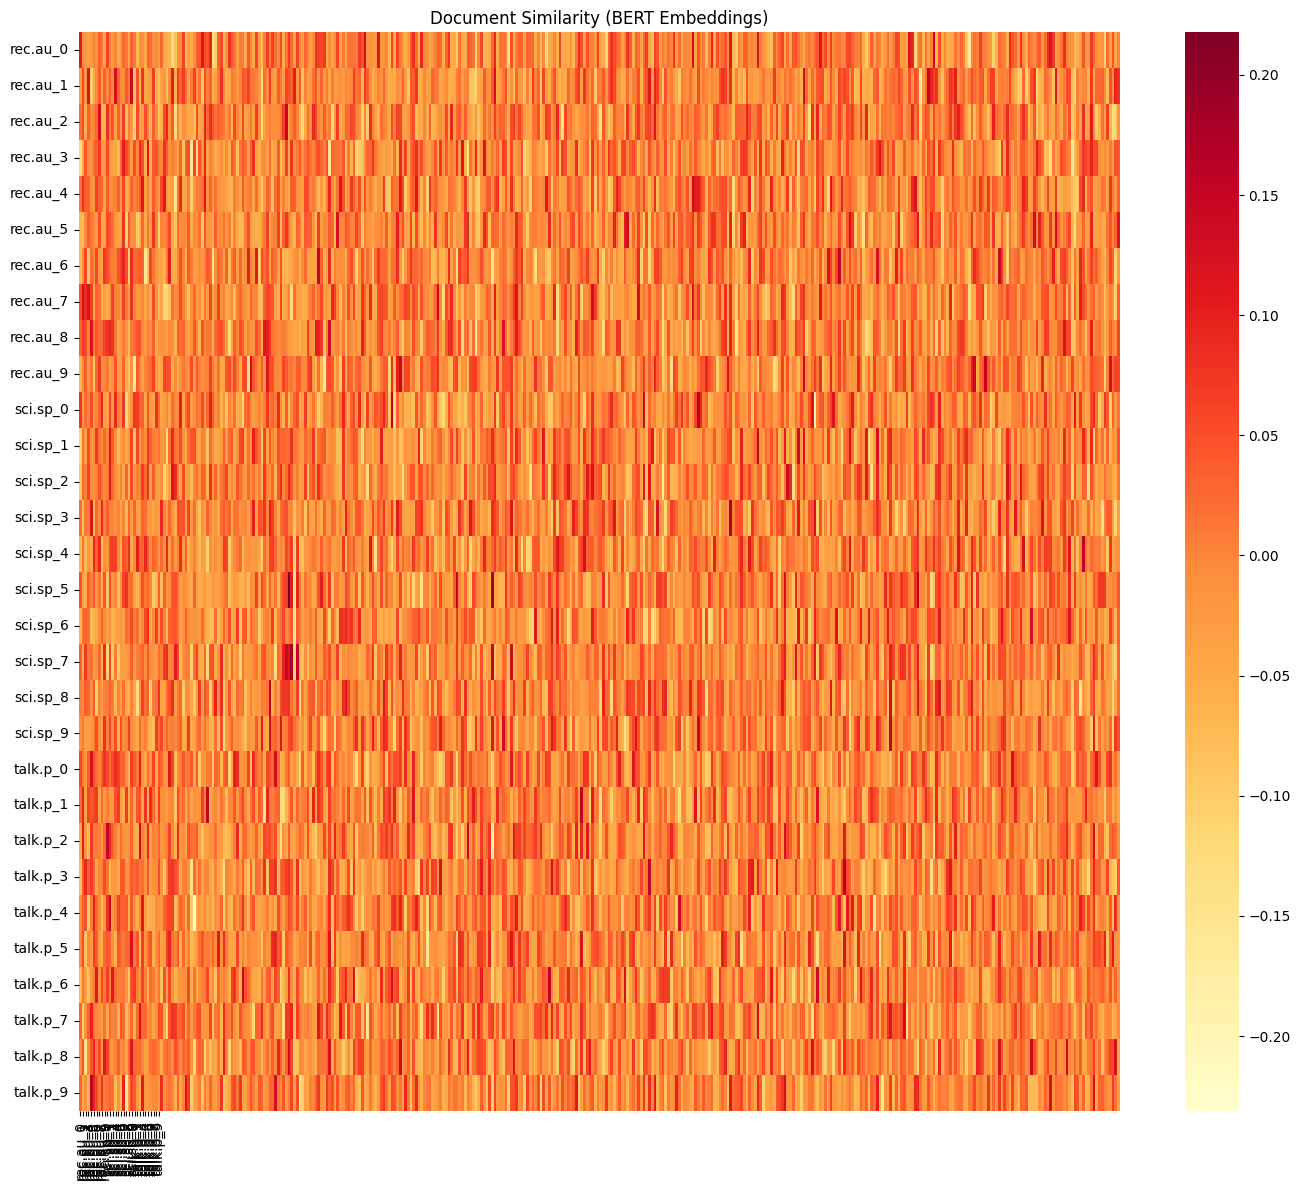

In [13]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: TF-IDF shows clearer clustering by category than BERT in this case.

2. Differences between methods: Yes, there are noticeable differences. TF-IDF tends to group documents more clearly within the same category because it relies on shared vocabulary, so documents with similar words (e.g., “car”, “engine”, “space”, “government”) appear more similar. In contrast, the BERT heatmap appears more diffuse, with less obvious block structures, meaning it does not cluster categories as cleanly.

This happens because BERT captures semantic meaning rather than exact word overlap. As a result, documents from different categories may appear similar if they discuss related concepts (e.g., technology in both space and politics), even if they use different words. On the other hand, TF-IDF only considers word frequency, so it separates categories more strictly.

3. Preferred method for classification: I would prefer BERT embeddings for a document classification task.

Even though TF-IDF shows clearer clustering in this visualization, BERT captures deeper semantic relationships between words and documents. This allows it to generalize better, especially when documents use different vocabulary to express similar ideas. TF-IDF is limited to surface-level word matching, while BERT understands context and meaning, which is more important for real-world classification tasks.

### Exercise C.2: Semantic Search with BERT

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    
    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return
        
    Returns:
        list: List of (index, similarity_score) tuples
    """
    # 1. Encode the query
    query_embedding = model.encode([query], convert_to_numpy=True)
    
    # 2. Encode all documents
    doc_embeddings = model.encode(documents, convert_to_numpy=True)
    
    # 3. Compute similarity with all documents
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    
    # 4. Return top_k most similar
    top_indices = similarities.argsort()[::-1][:top_k]
    results = [(idx, similarities[idx]) for idx in top_indices]
    
    return results

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "space mission and NASA research"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'space mission and NASA research'

Top 5 most similar documents:

  Score: 0.5393
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.4249
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.2348
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.2299
  Category: talk.politics.misc
  Text: WHITE HOUSE
                   OFFICE OF THE VICE PRESIDENT
_________________________________________________________________

FOR IMMEDIATE RELEASE  ...

  Score: 0.2061
  Category: sci.space
  Text: Sterrenkundig symposium 'Compacte Objecten'
                        

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance:
Yes, most of the results are relevant to the query. The query was about space missions, NASA, and research, and the top results include documents discussing the space program, NASA funding, and the Kennedy Space Center. These are clearly connected to the meaning of the query, even when the exact wording is not identical. This shows that the semantic search is capturing topic meaning rather than relying only on exact keyword matches.

2. Category accuracy: The search mostly identified documents from the expected category, which is sci.space. Four of the top five results came from sci.space, so the category accuracy is strong overall. One result came from talk.politics.misc, but that still makes sense because it appears to discuss the Vice President / White House, which can overlap with NASA funding and government support for the space program. So the cross-category result is not completely wrong; it reflects a real thematic overlap.

3. Ambiguous query test: If I use a query that could match multiple categories, such as “government funding for the space program”, I would expect the search to return a mix of sci.space and talk.politics.misc documents. This is because the query combines both space-related and political/government concepts. In that case, semantic search would likely retrieve documents from both categories, showing that it can capture overlapping themes rather than forcing results into only one category.

---

## Part D: Embedding Visualization with t-SNE

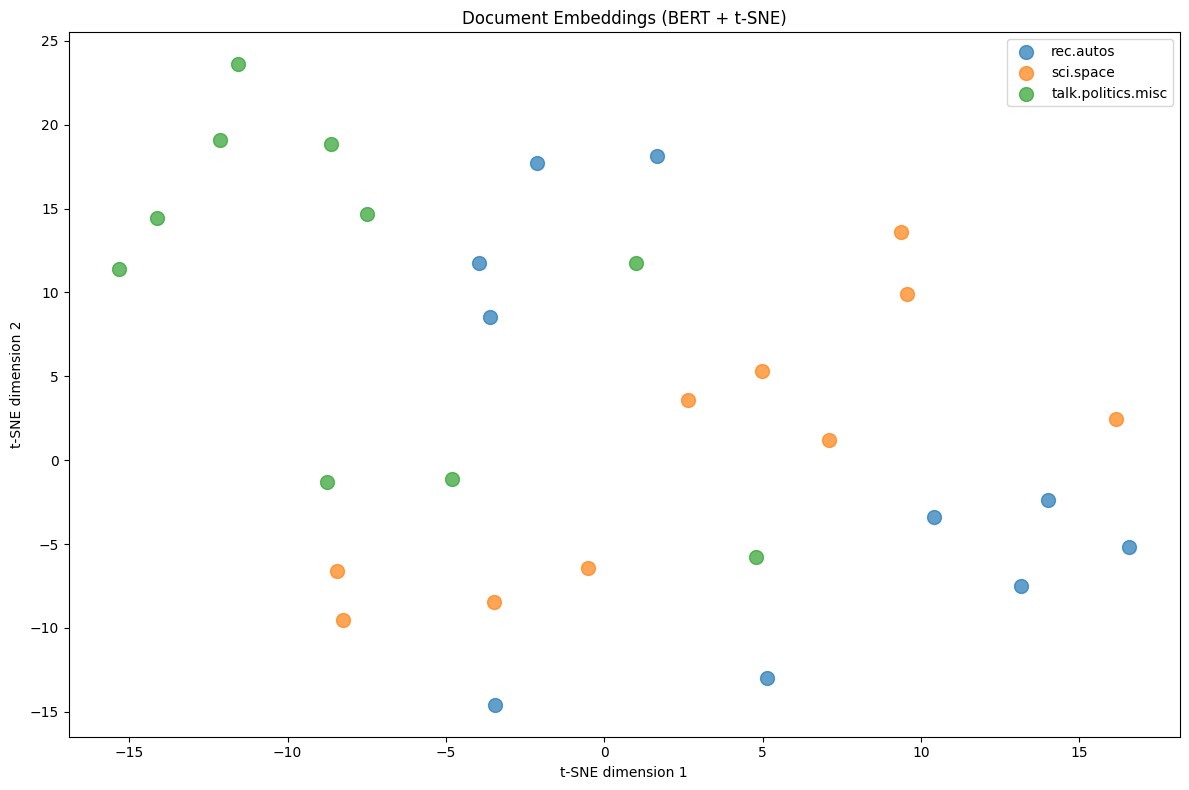

In [15]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {
    'rec.autos': 'red',
    'sci.space': 'blue',
    'talk.politics.misc': 'green'
}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: The categories form moderately distinct clusters, but they are not perfectly separated. The sci.space documents (orange) are relatively well grouped on one side of the plot, while rec.autos (blue) and talk.politics.misc (green) are more spread out and partially overlapping. This suggests that BERT embeddings capture some category-level structure, but the separation is not very sharp.

2. Misplaced documents: Yes, there are some documents that appear in the “wrong” cluster. For example, a few rec.autos points are located near or within regions dominated by talk.politics.misc, and some talk.politics.misc points are scattered among other categories. This could be explained by overlapping themes in the data. For instance, political discussions about regulations, taxes, or government policies can relate to automobiles, and discussions about government funding can overlap with space-related topics. Since BERT captures semantic meaning, it groups documents by contextual similarity, not just category labels.

3. Most similar categories: The most similar categories appear to be rec.autos and talk.politics.misc, as their points are more intermingled compared to sci.space, which is more clearly separated. This partially matches expectations from Part 1, where some overlap was observed due to shared general vocabulary (e.g., “government”, “policy”, or general discussion terms). However, the stronger separation of sci.space aligns well with its more specialized and technical vocabulary.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**  

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, fast, easy to interpret; captures word frequency clearly | Ignores context and word meaning; high dimensional and sparse | Baseline models, quick text classification, small datasets |
| TF-IDF | Reduces importance of common words; highlights important terms; better than BoW for topic separation | Still ignores context and semantics; cannot capture word relationships | Document classification, information retrieval |
| Word2Vec | Captures semantic relationships between words; dense representations | Needs large data for good performance; context-independent (same vector for all uses of a word) | Word similarity, analogy tasks, feature engineering |
| GloVe | Pre-trained on large corpora; strong general semantic understanding; stable embeddings | Not domain-specific; cannot adapt to specific dataset vocabulary | General NLP tasks, transfer learning |
| BERT | Captures deep contextual meaning; understands sentence-level semantics; handles ambiguity well | Computationally expensive; harder to interpret; may need fine-tuning | Semantic search, classification, question answering |

---

### 2. Best Method for My Dataset

For my dataset (`rec.autos`, `sci.space`, `talk.politics.misc`), **TF-IDF worked best overall for clear category separation**, while **BERT performed best for semantic understanding**.

From the bar charts and TF-IDF results, each category had distinct top words such as *“car”* for autos, *“space”* and *“nasa”* for space, and *“government”* for politics. The TF-IDF similarity heatmap also showed clearer clustering compared to BERT, indicating that it separated categories more effectively based on vocabulary.

However, BERT demonstrated stronger semantic capabilities. In the semantic search task, it successfully retrieved mostly `sci.space` documents for a query about NASA and space missions, even when exact keywords did not match. It also captured cross-category relationships, such as linking political documents discussing NASA funding with space-related topics.

Overall, TF-IDF was better for **clear classification boundaries**, while BERT was better for **understanding meaning and retrieving relevant content**.

---

### 3. My Recommendation for a Real System

For a real document classification system, I would use **BERT embeddings (or a fine-tuned BERT model)**.

This is because BERT captures contextual and semantic meaning, which allows it to handle variations in language, synonyms, and more complex expressions. While TF-IDF performed well in separating categories in this dataset, it relies heavily on exact word overlap and may fail when documents use different vocabulary to express similar ideas.

In a real-world system where language is more diverse and less predictable, BERT would generalize better and provide more accurate classification. Additionally, BERT can be fine-tuned on the dataset to further improve performance, making it a more powerful and flexible solution.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found